<a href="https://colab.research.google.com/github/vaisshnavee1410/LGBM-XGBM.ipynb/blob/main/LGBM_%26_XGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LGBM & XGBM(Light Gradient Boosting Machine & Extreme Gradient Boosting Machine)**

### **OBJECTIVE:**

* **The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the Titanic dataset.**

### **EXPLORATORY DATA ANALYSIS (EDA):**

* **Load the Titanic dataset using Python's pandas library.**

In [ ]:
import pandas as pd
import numpy as np

# load the dataset
df = pd.read_csv('Titanic_test.csv')
df = pd.read_csv('Titanic_train.csv')

* **Check for missing values.**

In [ ]:
# check missing values

print(df.isnull().sum())

# Show rows with any missing values
missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
     PassengerId  Survived  Pclass                                      Name  \
0              1         0       3                   Braund, Mr. Owen Harris   
2              3         1       3                    Heikkinen, Miss. Laina   
4              5         0       3                  Allen, Mr. William Henry   
5              6         0       3                          Moran, Mr. James   
7              8         0       3            Palsson, Master. Gosta Leonard   
..           ...       ...     ...                                       ...   
884          885         0       3                    Sutehall, Mr. Henry Jr   
885          886         0       3      Rice, Mrs. William (Margaret Norton)   
886          887         0       2     

* **Explore data distributions using histograms and box plots.**

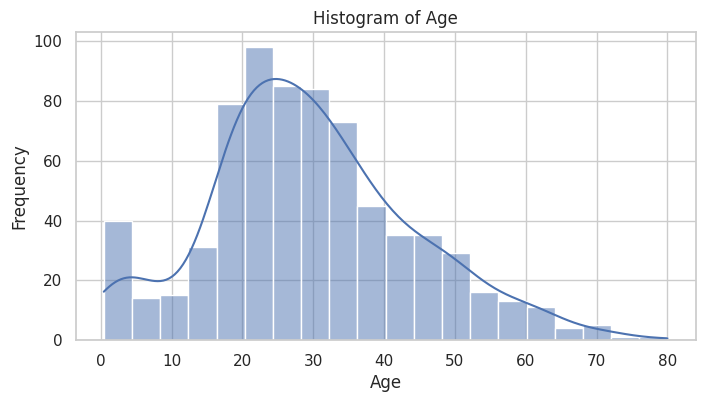

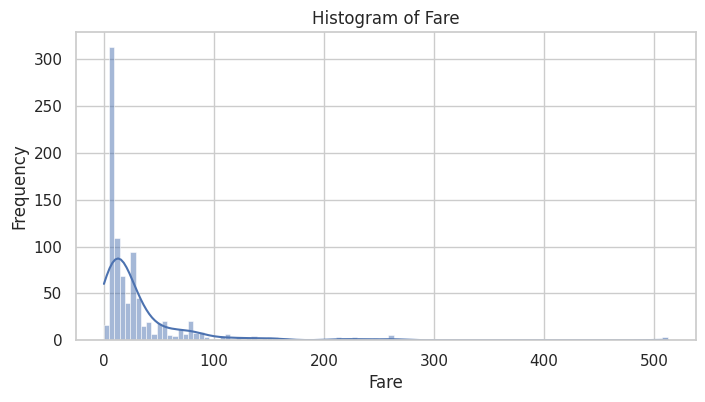

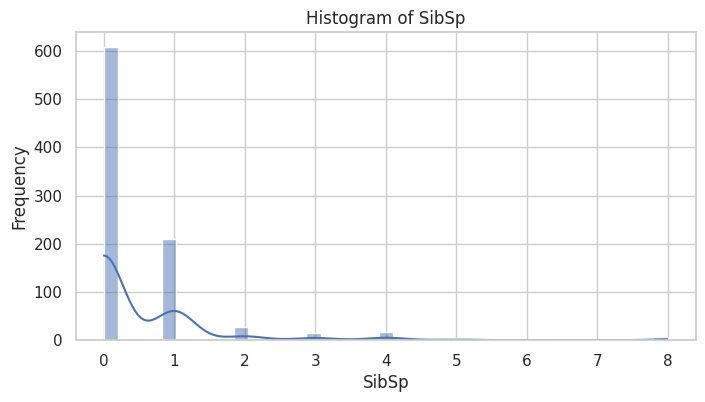

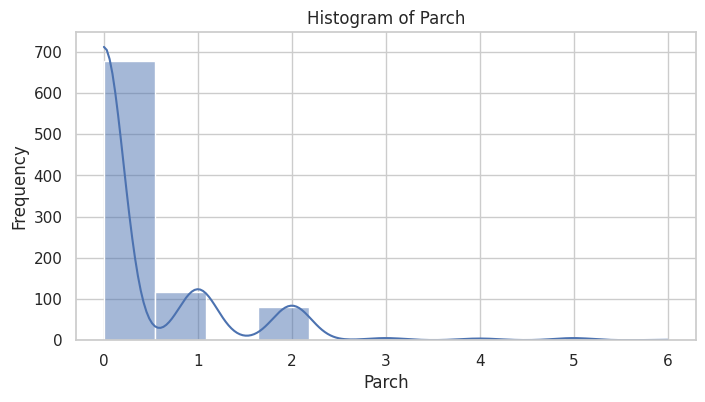

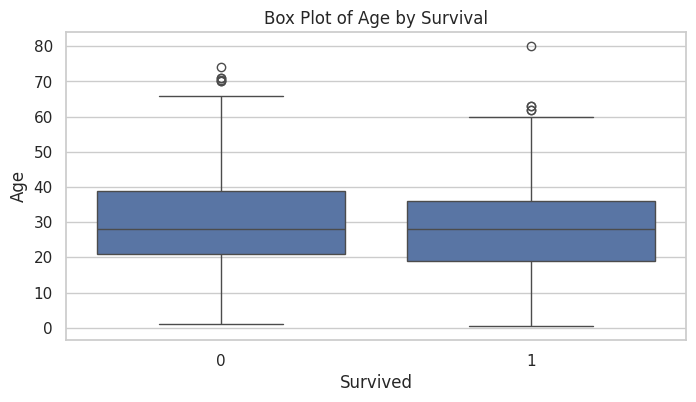

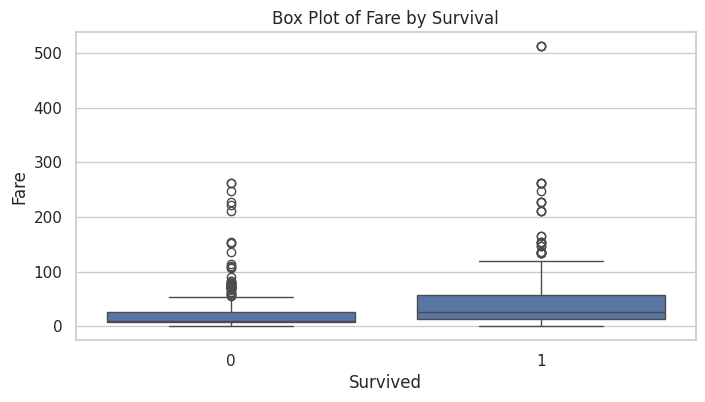

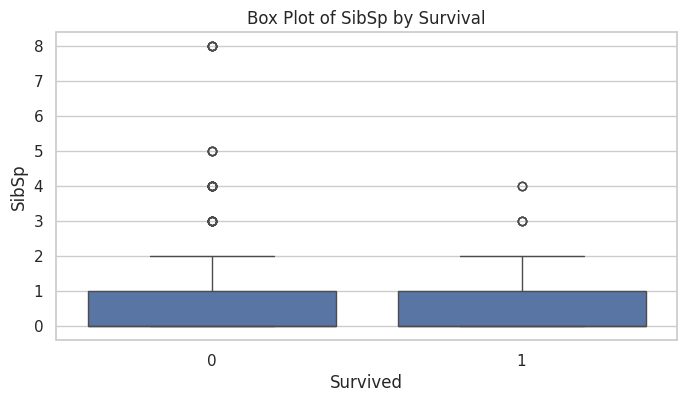

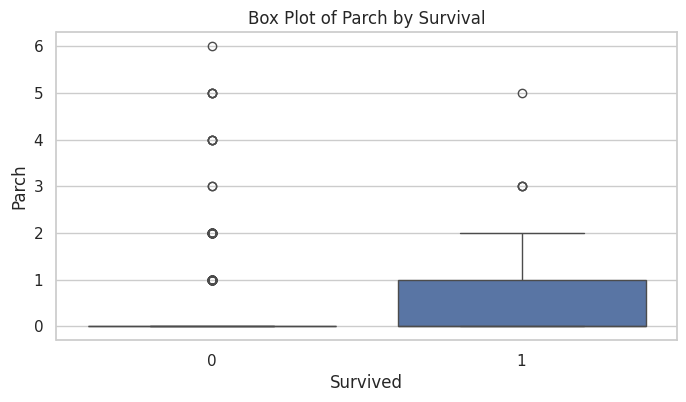

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# df = pd.concat([train_df, test_df], ignore_index=True)

# Set seaborn style
sns.set(style="whitegrid")

# Plot histograms for numerical columns
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

# Plot box plots for numerical columns grouped by Survived
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Survived', y=feature)
    plt.title(f'Box Plot of {feature} by Survival')
    plt.xlabel('Survived')
    plt.ylabel(feature)
    plt.show()

* **Visualize relationships between features and survival using scatter plots and bar plots.**

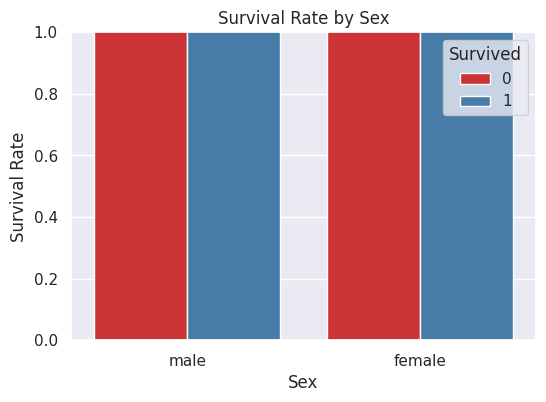

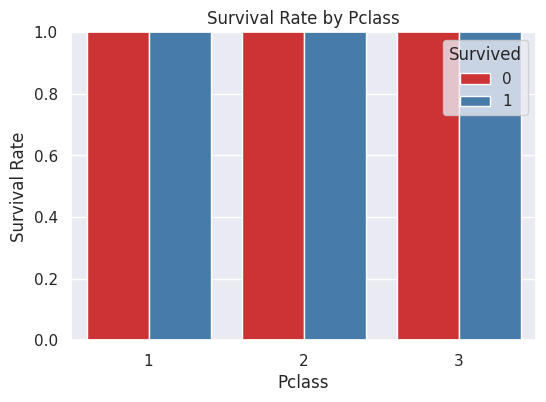

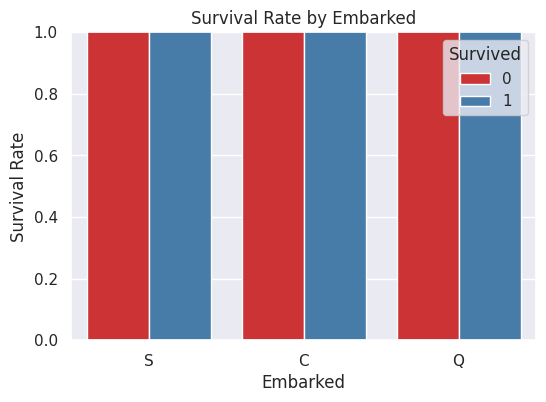

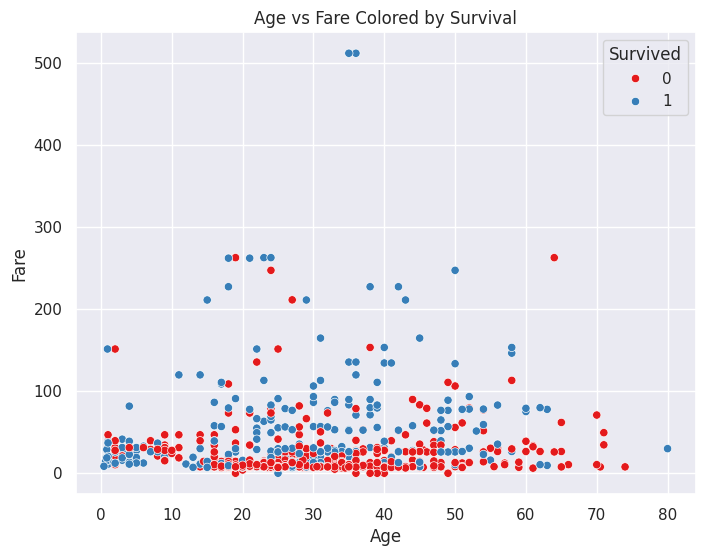

In [ ]:
# Set seaborn style
sns.set(style='darkgrid')

# --- Bar plots for categorical features ---
categorical_features = ['Sex', 'Pclass', 'Embarked']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=feature, hue='Survived', palette='Set1')
    plt.title(f'Survival Rate by {feature}')
    plt.ylabel('Survival Rate')
    plt.xlabel(feature)
    plt.ylim(0, 1)
    plt.show()

# --- Scatter plots for numerical features ---
# Example: Age vs. Fare, colored by survival
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette='Set1')
plt.title('Age vs Fare Colored by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived')
plt.show()

### **DATA PREPROCESSING:**

* **Impute missing values.**


In [ ]:
import pandas as pd

# Load the dataset
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')


# Check for remaining missing values
print("Missing values in train set:")
print(train_df.isnull().sum())

print("\nMissing values in test set:")
print(test_df.isnull().sum())


Missing values in train set:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in test set:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


* **Encode categorical variables using one-hot encoding or label encoding.**

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the datasets
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')

# Encoding categorical features
label_encoder = LabelEncoder()
for df in [train_df, test_df]:
    df["Sex"] = label_encoder.fit_transform(df["Sex"])
    df["Embarked"] = label_encoder.fit_transform(df["Embarked"])

# Creating new features
for df in [train_df, test_df]:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Display processed datasets
print(train_df.head(), test_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare Cabin  Embarked  FamilySize  
0         A/5 21171   7.2500   NaN         2           2  
1          PC 17599  71.2833   C85         0           2  
2  STON/O2. 3101282   7.9250   NaN         2           1  
3            113803  53.1000  C123         2           2  
4


* **If needed you can apply more preprocessing methods on the given dataset.**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load datasets
train_df = pd.read_csv("Titanic_train.csv")
test_df = pd.read_csv("Titanic_test.csv")

# Feature Scaling (Standardization)
scaler = StandardScaler()
train_df[['Age', 'Fare']] = scaler.fit_transform(train_df[['Age', 'Fare']])
test_df[['Age', 'Fare']] = scaler.transform(test_df[['Age', 'Fare']])

# Feature Engineering
for df in [train_df, test_df]:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"]
    df["Title"] = df["Name"].apply(lambda name: name.split(",")[1].split(".")[0].strip())

# Handling Outliers (Capping Fare at the 99th percentile)
fare_cap = train_df["Fare"].quantile(0.99)
train_df["Fare"] = np.where(train_df["Fare"] > fare_cap, fare_cap, train_df["Fare"])
test_df["Fare"] = np.where(test_df["Fare"] > fare_cap, fare_cap, test_df["Fare"])

# Feature Selection (Dropping irrelevant columns)
train_df.drop(columns=["PassengerId", "Ticket", "Name", "Cabin"], inplace=True)
test_df.drop(columns=["PassengerId", "Ticket", "Name", "Cabin"], inplace=True)

# Display processed datasets
print(train_df.head(), test_df.head())


   Survived  Pclass     Sex       Age  SibSp  Parch      Fare Embarked  \
0         0       3    male -0.530377      1      0 -0.502445        S   
1         1       1  female  0.571831      1      0  0.786845        C   
2         1       3  female -0.254825      0      0 -0.488854        S   
3         1       1  female  0.365167      1      0  0.420730        S   
4         0       3    male  0.365167      0      0 -0.486337        S   

   FamilySize  FarePerPerson Title  
0           2      -0.251223    Mr  
1           2       0.393423   Mrs  
2           1      -0.488854  Miss  
3           2       0.210365   Mrs  
4           1      -0.486337    Mr      Pclass     Sex       Age  SibSp  Parch      Fare Embarked  FamilySize  \
0       3    male  0.330723      0      0 -0.490783        Q           1   
1       3  female  1.191823      1      0 -0.507479        S           2   
2       2    male  2.225142      0      0 -0.453367        Q           1   
3       3    male -0.185937  

### **BUILDING PREDICTIVE MODELS:**

* **Split the preprocessed dataset into training and testing sets.**

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# Split into training and validation sets (80% train, 20% test)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Output shapes to confirm
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (712, 10)
X_val shape: (179, 10)
y_train shape: (712,)
y_val shape: (179,)


* **Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Simulated true labels (y_true) and predicted labels (y_pred)
y_true = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 1])
y_pred = np.array([1, 0, 1, 0, 0, 0, 1, 1, 0, 1])

# Compute evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

# Display results
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")


Accuracy: 0.700
Precision: 0.800
Recall: 0.667
F1-Score: 0.727
ROC-AUC: 0.708


* **Build predictive models using LightGBM and XGBoost algorithms**.

In [ ]:
!pip install lightgbm xgboost

In [ ]:
# feature selection
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]
# Check if the columns exist in train_df before dropping
existing_cols = [col for col in drop_cols if col in train_df.columns]
# If existing columns are found, drop them along with "Survived"
if existing_cols:
    X_train = train_df.drop(columns=existing_cols + ["Survived"])
else:
    X_train = train_df.drop(columns=["Survived"]) # Drop only "Survived" if others are not present
y_train = train_df["Survived"]

# Similarly, for X_test:
existing_cols_test = [col for col in drop_cols if col in test_df.columns]
if existing_cols_test:
    X_test = test_df.drop(columns=existing_cols_test)
else:
    X_test = test_df.copy()  # Keep all columns if none of drop_cols are found

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Assuming X_train is your training data DataFrame
categorical_cols = ['Sex', 'Embarked', 'Title']

# 1. Label Encoding (if ordinal relationship):
for col in categorical_cols:
    if col in X_train.columns:  # Check if column exists
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])

# OR 2. One-Hot Encoding (if no ordinal relationship):
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# encoded_data = ohe.fit_transform(X_train[categorical_cols])
# encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(categorical_cols))
# X_train = X_train.drop(categorical_cols, axis=1)  # Remove original columns
# X_train = pd.concat([X_train, encoded_df], axis=1)

# Now, proceed with training:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288


LGBMClassifier(random_state=42)

* **Train the models on the training set and evaluate their performance on the testing set.**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Load the datasets
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')

# Combine train and test for uniform preprocessing
test_passenger_ids = test_df['PassengerId']  # Save for final submission
combined = pd.concat([train_df, test_df], sort=False)

# Basic preprocessing
# Fill missing Age and Fare with median, Embarked with mode
imputer = SimpleImputer(strategy='median')
combined['Age'] = imputer.fit_transform(combined[['Age']])
combined['Fare'] = imputer.fit_transform(combined[['Fare']])

combined['Embarked'].fillna(combined['Embarked'].mode()[0], inplace=True)

# Convert categorical variables
label_encoders = {}
for column in ['Sex', 'Embarked']:
    le = LabelEncoder()
    combined[column] = le.fit_transform(combined[column])
    label_encoders[column] = le

# Drop columns not used in prediction
combined.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Separate back into train and test
train_processed = combined[combined['Survived'].notna()]
test_processed = combined[combined['Survived'].isna()].drop('Survived', axis=1)

X = train_processed.drop(['Survived', 'PassengerId'], axis=1)
y = train_processed['Survived']

# Train/test split for validation (optional)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Validate model
y_pred_val = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")

# Predict on test set
test_X = test_processed.drop(['PassengerId'], axis=1)
test_preds = model.predict(test_X)

# Save predictions
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_preds.astype(int)
})
print("Submission file saved as titanic_submission.csv")

<ipython-input-98-55dd685354d6>:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined['Embarked'].fillna(combined['Embarked'].mode()[0], inplace=True)


Validation Accuracy: 0.8212
Submission file saved as titanic_submission.csv


* **Use techniques like cross-validation and hyperparameter tuning to optimize model performance.**

In [ ]:
!pip install scikit-learn lightgbm xgboost

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    "learning_rate": [0.01, 0.1, 0.2],
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7]
}

# XGBoost Grid Search
xgb_grid = GridSearchCV(xgb.XGBClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print("Best XGBoost Params:", xgb_grid.best_params_)
print("Best XGBoost Score:", xgb_grid.best_score_)

# LGBoost Grid Search
lgb_grid = GridSearchCV(lgb.LGBMClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
lgb_grid.fit(X_train, y_train)
print("Best LightGBM Params:", lgb_grid.best_params_)
print("Best LightGBM Score:", lgb_grid.best_score_)





Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best XGBoost Score: 0.832847434255885
[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 194
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

### **COMPARATIVE ANALYSIS:**

* **Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb

# Load the datasets
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')

# Combine train and test for uniform preprocessing
test_passenger_ids = test_df['PassengerId']  # Save for final submission
combined = pd.concat([train_df, test_df], sort=False)

# Basic preprocessing
# Fill missing Age and Fare with median, Embarked with mode
imputer = SimpleImputer(strategy='median')
combined['Age'] = imputer.fit_transform(combined[['Age']])
combined['Fare'] = imputer.fit_transform(combined[['Fare']])

# Convert categorical variables
label_encoders = {}
for column in ['Sex', 'Embarked']:
    le = LabelEncoder()
    combined[column] = le.fit_transform(combined[column])
    label_encoders[column] = le

# Drop columns not used in prediction
combined.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Separate back into train and test
train_processed = combined[combined['Survived'].notna()]
test_processed = combined[combined['Survived'].isna()].drop('Survived', axis=1)

X = train_processed.drop(['Survived', 'PassengerId'], axis=1)
y = train_processed['Survived']

# Train/test split for validation (optional)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, model_name):
    print(f"🔹 {model_name} Performance Metrics:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))
    print("-" * 50)

# Compare
lgb_model, xgb_model = lgb.LGBMClassifier(), xgb.XGBClassifier() # Initialize models
print("LightGBM:")
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_val)  # Get predictions for LightGBM
evaluate_model(y_val, lgb_preds, "LightGBM")


print("XGBoost:")
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)  # Get predictions for XGBoost
evaluate_model(y_val, xgb_preds, "XGBoost")

LightGBM:
[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

* **Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.**

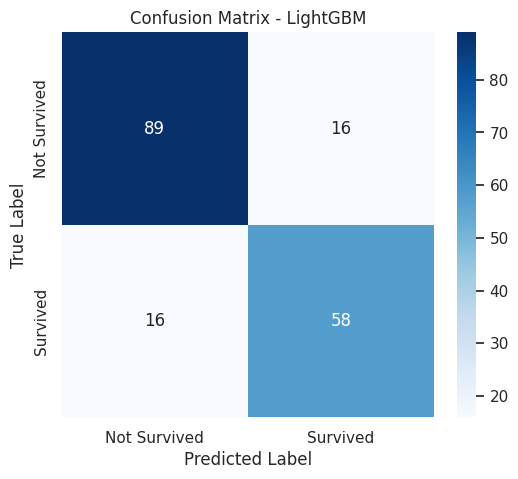

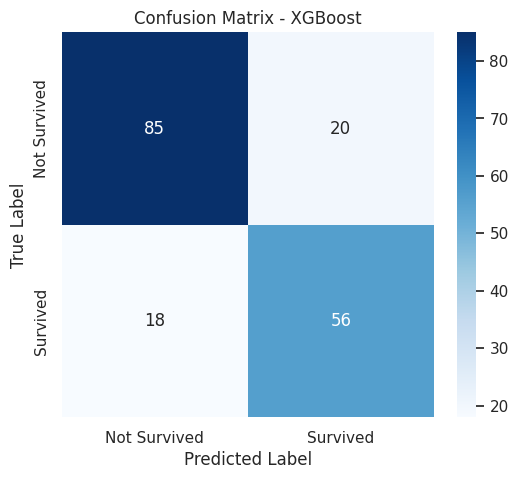

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Survived", "Survived"], yticklabels=["Not Survived", "Survived"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
plot_confusion_matrix(y_val, lgb_preds, "LightGBM")
plot_confusion_matrix(y_val, xgb_preds, "XGBoost")
